In [12]:
import pandas as pd
import numpy as np
import time
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import accuracy_score

In [13]:
data = pd.read_csv("Bitext_Sample_Customer_Support_Training_Dataset_27K_responses-v11.csv")

data.head()

,flags,instruction,category,intent,response
0,B,question about cancelling order {{Order Number}},ORDER,cancel_order,I've understood you have a question regarding ...
1,BQZ,i have a question about cancelling oorder {{Or...,ORDER,cancel_order,I've been informed that you have a question ab...
2,BLQZ,i need help cancelling puchase {{Order Number}},ORDER,cancel_order,I can sense that you're seeking assistance wit...
3,BL,I need to cancel purchase {{Order Number}},ORDER,cancel_order,I understood that you need assistance with can...
4,BCELN,"I cannot afford this order, cancel purchase {{...",ORDER,cancel_order,I'm sensitive to the fact that you're facing f...


In [14]:
print(data.columns)

Index(['flags', 'instruction', 'category', 'intent', 'response'], dtype='object')


In [15]:
data = data[['instruction','intent','response']]

data = data.dropna()

data.columns = ['query','intent','response']

data.head()

,query,intent,response
0,question about cancelling order {{Order Number}},cancel_order,I've understood you have a question regarding ...
1,i have a question about cancelling oorder {{Or...,cancel_order,I've been informed that you have a question ab...
2,i need help cancelling puchase {{Order Number}},cancel_order,I can sense that you're seeking assistance wit...
3,I need to cancel purchase {{Order Number}},cancel_order,I understood that you need assistance with can...
4,"I cannot afford this order, cancel purchase {{...",cancel_order,I'm sensitive to the fact that you're facing f...


In [16]:
X = data['query']
y = data['intent']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [17]:
vectorizer = TfidfVectorizer(
    stop_words='english',
    max_features=5000
)

X_train_vec = vectorizer.fit_transform(X_train)

X_test_vec = vectorizer.transform(X_test)

In [18]:
start = time.time()

correct = 0

for i in range(len(X_test)):

    query_vec = X_test_vec[i]

    sims = cosine_similarity(query_vec, X_train_vec)

    best_index = np.argmax(sims)

    predicted_intent = y_train.iloc[best_index]

    true_intent = y_test.iloc[i]

    if predicted_intent == true_intent:
        correct += 1

baseline_accuracy = correct / len(X_test)

baseline_time = time.time() - start

print("Baseline Accuracy:", baseline_accuracy)
print("Baseline Time:", baseline_time)

Baseline Accuracy: 0.9674418604651163
Baseline Time: 11.925592184066772


In [24]:
from sklearn.linear_model import SGDClassifier
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import time

# Train classifier
classifier = SGDClassifier(random_state=42)
classifier.fit(X_train_vec, y_train)

start = time.time()

correct = 0
y_pred_hybrid = []
y_true_hybrid = []

for i in range(len(X_test)):
    query = X_test.iloc[i]
    query_vec = vectorizer.transform([query])

    # Step 1: Predict intent (ML)
    pred_intent = classifier.predict(query_vec)[0]

    # Step 2: Get indices (FIXED indexing)
    subset_idx = np.where(y_train.values == pred_intent)[0]

    if len(subset_idx) == 0:
        continue

    subset_vec = X_train_vec[subset_idx]

    # Step 3: Similarity within subset
    sims = cosine_similarity(query_vec, subset_vec)

    best_local_index = np.argmax(sims)
    best_global_index = subset_idx[best_local_index]

    predicted_intent = y_train.iloc[best_global_index]
    true_intent = y_test.iloc[i]

    # Accuracy calculation
    if predicted_intent == true_intent:
        correct += 1

    # Store for confusion matrix
    y_pred_hybrid.append(predicted_intent)
    y_true_hybrid.append(true_intent)

hybrid_accuracy = correct / len(X_test)
hybrid_time = time.time() - start

print("Hybrid Accuracy:", hybrid_accuracy)
print("Hybrid Time:", hybrid_time)

Hybrid Accuracy: 0.9784186046511628
Hybrid Time: 9.495568752288818


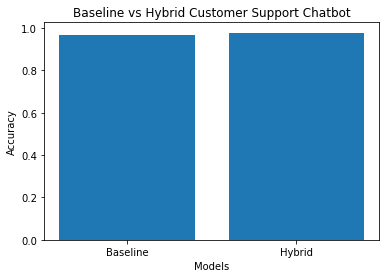

In [25]:
models = ["Baseline","Hybrid"]

accuracy = [baseline_accuracy, hybrid_accuracy]

plt.bar(models, accuracy)

plt.title("Baseline vs Hybrid Customer Support Chatbot")

plt.ylabel("Accuracy")

plt.xlabel("Models")

plt.show()

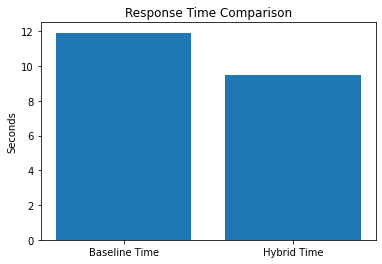

In [26]:
labels = ['Baseline Time','Hybrid Time']
values = [baseline_time,hybrid_time]

plt.figure(figsize=(6,4))

plt.bar(labels,values)

plt.title("Response Time Comparison")

plt.ylabel("Seconds")

plt.show()

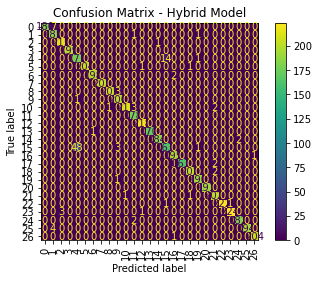

In [27]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(y_true_hybrid, y_pred_hybrid)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(xticks_rotation=90)

plt.title("Confusion Matrix - Hybrid Model")
plt.show()

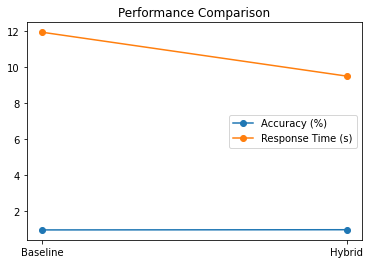

In [28]:
import matplotlib.pyplot as plt

models = ['Baseline', 'Hybrid']
accuracy = [baseline_accuracy, hybrid_accuracy]
time = [baseline_time,hybrid_time]

plt.figure()
plt.plot(models, accuracy, marker='o', label='Accuracy (%)')
plt.plot(models, time, marker='o', label='Response Time (s)')

plt.title("Performance Comparison")
plt.legend()

plt.show()

In [34]:
while True:
    q = input("User: ")

    if q.lower() == "exit":
        print("Chat ended.")
        break

    query_vec = vectorizer.transform([q])

    # Predict intent
    pred_intent = classifier.predict(query_vec)[0]

    # Filter data
    subset = data[data['intent'] == pred_intent]

    if subset.shape[0] == 0:
        print("Bot: Sorry, I didn't understand your query.")
        continue

    # Similarity
    subset_vec = vectorizer.transform(subset['query'])
    sims = cosine_similarity(query_vec, subset_vec)

    best_index = np.argmax(sims)
    response = subset.iloc[best_index]['response']

    print("Bot:", response)

User: change password
Bot: Definitely! I'm here to guide you through the process of retrieving your password and ensuring you regain access to your account smoothly and securely.

To retrieve your password, please follow these steps:

1. Visit our platform's login page at "{{Login Page URL}}".
2. Locate the option for password retrieval, typically labeled as "{{Forgot Password}}" or something similar.
3. Click on the "{{Forgot Password}}" button to initiate the password recovery process.
4. You may be prompted to enter your email address associated with your account.
5. Once you've entered your email address, click on the submit button to proceed.
6. A password reset email will be sent to the email address you provided. Please check your inbox, including the spam or junk folders, just in case.
7. Open the password reset email and carefully follow the instructions provided.
8. You will generally be redirected to a webpage where you can create a new password for your account. Ensure you 